# Deteção de Anomalias em Dados Cripto Multi-Exchange
## Processamento de Big Data — Tema 5

| Campo | Detalhe |
|---|---|
| **Docente** | Pedro Sobreiro |
| **UC** | Processamento de Big Data |
| **Ano Letivo** | 2025/2026 |
| **Tema** | Tema 5 — Anomalias Multi-Exchange |
| **Elementos do Grupo** | Ana Sofia — a22511208 / Bruno Proença — a22511734 / João Resina — a22512112 |
| **Dados** | BTC/USDT real — Binance, Kucoin, Coinbase (ccxt, 100 000+ registos) |

---




## Repositório GitHub e Ambiente de Desenvolvimento

### Ambiente de Desenvolvimento — Docker + JupyterLab
Para garantir que o ambiente é **100% reproduzível** — ou seja, que qualquer pessoa consegue correr este notebook sem problemas de versões ou dependências, foi utilizado **Docker** para criar um contentor isolado com todas as bibliotecas já instaladas.

O Docker funciona como uma "caixa" fechada que contém o sistema operativo, o Python, o PySpark, e todas as restantes bibliotecas, sempre na mesma versão, independentemente do computador onde é executado.

**Como foi feito:**

O ponto de partida foi o ficheiro `.yml` disponibilizado pelo professor Pedro Sobreiro no repositório oficial da UC: github.com/pesobreiro/big_data


Este ficheiro define o ambiente Conda com todas as dependências necessárias para a UC (PySpark 3.5, Python 3.11, Jupyter, pandas, matplotlib, etc.). A imagem Docker foi construída a partir desse ficheiro, garantindo que as versões usadas neste trabalho são exactamente as mesmas que o professor utiliza nas aulas.

**Passos para reproduzir o ambiente:**

```bash
# 1. Clonar o repositório do trabalho
git clone github.com/brunoproenca03/TP_Anomalias

# 2. Entrar na pasta
cd TP_Anomalias

# 3. Arrancar o contentor Docker com JupyterLab
docker compose up

# 4. Abrir o browser em localhost:8888
# e navegar até ao notebook Tema5_DetacaoAnomalias.ipynb
```

> **Nota:** O JupyterLab arranca automaticamente dentro do contentor com todas as dependências já instaladas. Não é necessário fazer `pip install` de nada — o ambiente está completo e pronto a usar.

---
## Introdução

O mercado de criptomoedas funciona 24 horas por dia em dezenas de plataformas chamadas *exchanges* em simultâneo. O mesmo ativo — neste caso o Bitcoin (BTC/USDT) — é negociado ao mesmo tempo na **Binance**, na **Kucoin** e na **Coinbase**. Em condições normais, o preço é praticamente igual nas três. Mas em momentos excepcionais ocorrem anomalias: o preço colapsa 15–20% numa exchange mas nas outras não (*flash crash*), o volume de negociação dispara 10 vezes sem razão aparente, ou a diferença de preço entre plataformas torna-se suficientemente grande para sugerir manipulação. Detetar estes eventos automaticamente tem valor directo para sistemas de alerta de risco, reguladores e investidores.

**Dataset:** Dados OHLCV reais extraídos com a biblioteca `ccxt`, armazenados em três ficheiros Parquet: `data/binance_btc.parquet`, `data/kucoin_btc.parquet`, `data/coinbase_btc.parquet`. Cada ficheiro contém mais de 100 000 linhas. As colunas são `timestamp`, `open`, `high`, `low`, `close` e `volume`.

**Hipótese:** A combinação do **Z-score distribuído** (Spark SQL/Window) com o **BisectingKMeans** nativo do `pyspark.ml` deteta anomalias de forma completamente distribuída — sem nunca transferir o dataset completo para a memória de um único nó.

**Arquitetura Medallion:**
```
Bronze  →  Parquet brutos por exchange (dados originais do ccxt) (Sobreiro, 2025)
Silver  →  alinhamento temporal + feature engineering (Sobreiro, 2025)
Gold    →  scores de anomalia + flags de deteção (particionado) (Sobreiro, 2025)
```

**Alterações face ao template original:**

| Elemento original | Substituição |
|---|---|
| Dados sintéticos GBM | Parquet reais (ccxt) |
| `sklearn.IsolationForest` via `.toPandas()` | `pyspark.ml.clustering.BisectingKMeans` |
| `sklearn.StandardScaler` | `pyspark.ml.feature.StandardScaler` |
| Back-join Pandas → Spark | Eliminado — scoring 100% em Spark |


---
## Metodologia

Esta secção descreve passo a passo como o pipeline foi construído: desde a leitura dos dados brutos até à escrita do resultado final com as classificações de anomalia. Cada subsecção corresponde a uma fase do pipeline e explica tanto o *o quê* (o que o código faz) como o *porquê* (a razão técnica e financeira para cada escolha).




### Camada Bronze — Extração de Dados Reais (ccxt)

Antes de qualquer processamento com PySpark, é necessário extrair os dados históricos directamente das exchanges. Esta fase usa a biblioteca **`ccxt`** (*CryptoCurrency eXchange Trading Library*), uma ferramenta de código aberto que permite comunicar com centenas de exchanges de criptomoedas através de uma interface unificada. (Sobreiro, 2025)

**O que esta célula faz:**
- Liga-se às três exchanges (Binance, Kucoin, Coinbase) via API pública — sem chaves de autenticação
- Extrai barras OHLCV de 15 em 15 minutos a partir de 1 de Janeiro de 2021
- Itera em blocos de 1 000 registos até atingir 105 000 registos por exchange (margem de segurança acima dos 100 000 exigidos)
- Guarda cada ficheiro no formato **Parquet** na pasta `data/` para ser lido pelo pipeline PySpark

**Porquê Parquet e não CSV?** O Parquet é um formato colunar comprimido: para o mesmo dataset, ocupa cerca de 25–30% do espaço de um CSV e é lido 5 a 10 vezes mais rápido pelo Spark.

**Nota:** Esta célula só precisa de ser executada uma vez. Os ficheiros gerados são persistentes e servem como a **Camada Bronze** — os dados brutos, originais e imutáveis, que nunca são modificados pelas fases seguintes.

> ⚠️ A execução demora vários minutos (a biblioteca respeita os limites de velocidade de cada exchange com `time.sleep`). Se os ficheiros já existirem na pasta `data/`, pode saltar esta célula.

In [1]:
# ==========================================
# CAMADA BRONZE — Extração via ccxt
# ==========================================
# Instalar a biblioteca ccxt se ainda não estiver disponível
!pip install ccxt -q

import ccxt
import pandas as pd
import time
import os

# Garantir que a pasta data/ existe
os.makedirs("data", exist_ok=True)

# ── Configuração das três exchanges ──────────────────────────────────────────
# Cada exchange tem o seu próprio par de trading:
# - Binance e Kraken usam BTC/USDT (Tether, dólar sintético em blockchain)
# - Coinbase usa BTC/USD (dólar americano real)
# Os valores de preço são comparáveis pois USDT mantém paridade 1:1 com USD
configuracoes = {
    'binance':  'BTC/USDT',
    'kucoin':   'BTC/USDT',
    'coinbase': 'BTC/USD',
}

timeframe      = '15m'      # Uma barra a cada 15 minutos
registos_alvo  = 105_000    # 105k garante > 100k mesmo após limpeza e join

print("A iniciar extração de dados das 3 exchanges...\n")

# ── Ciclo de extração por exchange ───────────────────────────────────────────
for exchange_id, symbol in configuracoes.items():
    print(f"--- A extrair dados da {exchange_id.upper()} ---")

    # Inicializar o objeto da exchange (sem autenticação — dados públicos)
    exchange = getattr(ccxt, exchange_id)()

    # Ponto de partida: 1 de Janeiro de 2021 (em milissegundos, formato UNIX)
    # Escolhemos 2021 porque cobre >100k barras de 15min e inclui ciclos de mercado
    # completos (bull market 2021, bear market 2022, recuperação 2023-2024)
    since = exchange.parse8601('2021-01-01T00:00:00Z')

    todos_dados = []  # Acumulador das barras extraídas

    # Iterar até atingir o número alvo de registos
    while len(todos_dados) < registos_alvo:
        try:
            # Pedir 1 000 barras a partir do timestamp 'since'
            # A API devolve: [timestamp_ms, open, high, low, close, volume]
            dados = exchange.fetch_ohlcv(symbol, timeframe, since, limit=1000)

            # Se a exchange não tem mais dados (chegámos ao presente), parar
            if not dados:
                print(f"  Sem mais dados disponíveis na {exchange_id}.")
                break

            todos_dados.extend(dados)

            # Avançar o ponto de início para logo após a última barra recebida
            # (+1 ms evita duplicados na próxima iteração)
            since = dados[-1][0] + 1

            print(f"  Progresso {exchange_id}: {len(todos_dados):,} / {registos_alvo:,} registos...")

            # Respeitar o rate limit da exchange (evitar ser bloqueado)
            # rateLimit está em milissegundos; dividimos por 1000 para segundos
            time.sleep(exchange.rateLimit / 1000)

        except Exception as e:
            print(f"  Erro na {exchange_id}: {e}")
            break

    # ── Converter para DataFrame e guardar em Parquet ─────────────────────────
    if todos_dados:
        df = pd.DataFrame(
            todos_dados,
            columns=['timestamp', 'open', 'high', 'low', 'close', 'volume']
        )

        # Converter timestamp de milissegundos UNIX para datetime legível
        # dtype datetime64[us] é o formato esperado pelo PySpark
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms').astype('datetime64[us]')

        # Guardar em Parquet — sem índice, schema incluído no ficheiro
        caminho = f"data/{exchange_id}_btc.parquet"
        df.to_parquet(caminho, index=False)

        print(f"  SUCESSO: {exchange_id.upper()} → {len(df):,} registos → {caminho}\n")
    else:
        print(f"  AVISO: Nenhum dado foi extraído para {exchange_id}\n")

print("Extração (Camada Bronze) concluída!")
print("Ficheiros gerados:")
for eid in configuracoes:
    path = f"data/{eid}_btc.parquet"
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  {path}  ({size_kb:.0f} KB)")

A iniciar extração de dados das 3 exchanges...

--- A extrair dados da BINANCE ---
  Progresso binance: 1,000 / 105,000 registos...
  Progresso binance: 2,000 / 105,000 registos...
  Progresso binance: 3,000 / 105,000 registos...
  Progresso binance: 4,000 / 105,000 registos...
  Progresso binance: 5,000 / 105,000 registos...
  Progresso binance: 6,000 / 105,000 registos...
  Progresso binance: 7,000 / 105,000 registos...
  Progresso binance: 8,000 / 105,000 registos...
  Progresso binance: 9,000 / 105,000 registos...
  Progresso binance: 10,000 / 105,000 registos...
  Progresso binance: 11,000 / 105,000 registos...
  Progresso binance: 12,000 / 105,000 registos...
  Progresso binance: 13,000 / 105,000 registos...
  Progresso binance: 14,000 / 105,000 registos...
  Progresso binance: 15,000 / 105,000 registos...
  Progresso binance: 16,000 / 105,000 registos...
  Progresso binance: 17,000 / 105,000 registos...
  Progresso binance: 18,000 / 105,000 registos...
  Progresso binance: 19,00

### Setup — Importações, SparkSession e Configuração

In [2]:
# ── Instalar PySpark no Colab (remover comentário se necessário) ──────────────
# !pip install pyspark

import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml import Pipeline

# ── Directórios ───────────────────────────────────────────────────────────────
BASE   = os.getcwd()
SILVER = os.path.join(BASE, "data", "silver")
GOLD   = os.path.join(BASE, "data", "gold")
CHARTS = os.path.join(BASE, "charts")
for d in [SILVER, GOLD, CHARTS]:
    os.makedirs(d, exist_ok=True)

# ── Paths dos ficheiros Bronze (produzidos externamente pelo ccxt) ─────────────
# Schema esperado por ficheiro:
#   timestamp  datetime64[us]
#   open, high, low, close, volume  float64
BRONZE_FILES = {
    "binance":  os.path.join(BASE, "data", "binance_btc.parquet"),
    "kucoin":    os.path.join(BASE, "data", "kucoin_btc.parquet"),
    "coinbase": os.path.join(BASE, "data", "coinbase_btc.parquet"),
}

# ── Hiper-parâmetros do pipeline ──────────────────────────────────────────────

# Features usadas no detector Z-score
Z_FEATURES = [
    "returns_binance",
    "volatility7_binance",
    "vol_ratio_binance",
    "max_cross_gap",
    "price_range_binance",
]
Z_THRESH = 3.5   # limiar |z| para flag de anomalia

# Features completas para o pipeline ML (espelha IF_FEATURES do notebook original)
ML_FEATURES = [
    "returns_binance",    "volatility7_binance",
    "vol_ratio_binance",  "max_cross_gap",        "price_range_binance",
    "returns_kucoin",      "vol_ratio_kucoin",
    "returns_coinbase",   "vol_ratio_coinbase",
]

# BisectingKMeans
BKM_K                = 8     # número de clusters folha
BKM_MAX_ITER         = 20    # iterações máximas de bissecção
BKM_SEED             = 42
ANOMALY_CLUSTER_FRAC = 0.02  # clusters com ≤ 2% da população → anómalos
                              # (espelha contamination=0.02 do IsolationForest original)

# ── SparkSession ──────────────────────────────────────────────────────────────
# Para cluster real: remover .master("local[*]") e submeter via spark-submit.
# shuffle.partitions deve ser 2–3× o número de cores do cluster.
spark = (
    SparkSession.builder
    .appName("Tema5_AnomaliasCrypto_BigData")
    .config("spark.sql.ansi.enabled", "false")
    .config("spark.driver.memory", "4g")
    # ~128 MB por partição após shuffle — ajustar conforme o cluster
    .config("spark.sql.shuffle.partitions", "32")
    # Adaptive Query Execution (Spark 3.x): coalesce automático de partições pequenas
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"PySpark {spark.version} — sessão pronta")
print(f"UI: {spark.sparkContext.uiWebUrl}")


PySpark 3.5.0 — sessão pronta
UI: http://caa1bbe77a5f:4040


---
### Camada Silver — Fase 1: Leitura e Alinhamento Temporal

O primeiro passo é ler os três ficheiros Parquet e juntá-los numa única tabela. Para isso, é feito um **join interno** (*inner join*) na coluna `timestamp`. Um join interno significa: só ficam no resultado final as linhas onde os três ficheiros têm dados exactamente no mesmo instante de tempo. Se a Binance tem dados das 14:00:00 mas a Kucoin não tem, essa linha é eliminada. (Apache Software Foundation, 2024; Zaharia et al., 2016)

Isto é importante porque não faz sentido comparar o preço da Binance das 14:00 com o preço da Kucoin das 14:01 — são momentos diferentes e a comparação seria enganosa. Só podemos calcular a divergência de preço entre exchanges se estamos a olhar para o mesmo instante. (Apache Software Foundation, 2024; Zaharia et al., 2016)

Antes do join, as colunas de preço de cada ficheiro são renomeadas com o sufixo da exchange. Por exemplo, a coluna `close` do ficheiro da Binance passa a chamar-se `close_binance`, e a da Kucoin passa a chamar-se `close_kucoin`. Sem esta renomeação, quando as três tabelas fossem unidas, haveria três colunas chamadas `close` e o Spark não saberia qual era qual. (Apache Software Foundation, 2024; Zaharia et al., 2016)

Após o join, é aplicado `na.drop()` para remover linhas que tenham valores em falta. Estes valores nulos podem aparecer, por exemplo, em períodos sem negociação ou em páginas Parquet corrompidas. (Apache Software Foundation, 2024; Zaharia et al., 2016)


In [3]:
def read_and_rename(exchange: str, path: str):
    """
    Lê um ficheiro Parquet Bronze, garante o tipo correto da coluna timestamp,
    e renomeia as colunas OHLCV com o sufixo do exchange.

    Parâmetros
    ----------
    exchange : str   Sufixo de coluna (e.g. "binance").
    path     : str   Caminho absoluto para o ficheiro Parquet.

    Retorna
    -------
    pyspark.sql.DataFrame
        Colunas: timestamp | open_<exch> | high_<exch> | low_<exch>
                 | close_<exch> | volume_<exch>
    """
    sdf = spark.read.parquet(path)

    # Cast defensivo: ccxt pode escrever INT96 ou TIMESTAMP_MICROS no Parquet
    sdf = sdf.withColumn("timestamp", F.col("timestamp").cast("timestamp"))

    # Renomear OHLCV com sufixo do exchange para evitar colisões no join
    for col in ["open", "high", "low", "close", "volume"]:
        sdf = sdf.withColumnRenamed(col, f"{col}_{exchange}")

    # Estatísticas descritivas rápidas
    row = sdf.agg(
        F.count("*").alias("rows"),
        F.round(F.min(f"close_{exchange}"), 2).alias("price_min"),
        F.round(F.max(f"close_{exchange}"), 2).alias("price_max"),
        F.round(F.mean(f"volume_{exchange}"), 4).alias("vol_mean"),
    ).first()
    print(
        f"  Bronze ✓ {exchange:10s}  rows={row.rows:,}  "
        f"close=[{row.price_min:,.0f} – {row.price_max:,.0f}]  "
        f"vol_mean={row.vol_mean:.4f}"
    )
    return sdf


print("=== Leitura dos ficheiros Bronze ===")
sdf_binance  = read_and_rename("binance",  BRONZE_FILES["binance"])
sdf_kucoin    = read_and_rename("kucoin",    BRONZE_FILES["kucoin"])
sdf_coinbase = read_and_rename("coinbase", BRONZE_FILES["coinbase"])

print("\nSchema (Binance — idêntico para todos os exchanges):")
sdf_binance.printSchema()


=== Leitura dos ficheiros Bronze ===
  Bronze ✓ binance     rows=105,000  close=[15,650 – 68,719]  vol_mean=1100.6345
  Bronze ✓ kucoin      rows=105,895  close=[15,649 – 68,742]  vol_mean=78.6499
  Bronze ✓ coinbase    rows=105,278  close=[15,633 – 68,733]  vol_mean=192.4201

Schema (Binance — idêntico para todos os exchanges):
root
 |-- timestamp: timestamp (nullable = true)
 |-- open_binance: double (nullable = true)
 |-- high_binance: double (nullable = true)
 |-- low_binance: double (nullable = true)
 |-- close_binance: double (nullable = true)
 |-- volume_binance: double (nullable = true)



In [4]:
# ── Join temporal (inner) nas três exchanges ──────────────────────────────────
# O join inner em timestamp garante que só os instantes presentes nas três
# plataformas em simultâneo são retidos.
#
# NOTA DISTRIBUÍDA:
# Com 100k+ linhas, um join de três vias dispara um shuffle. Para evitar o
# sort-merge join e usar broadcast join (mais rápido para DataFrames menores),
# descomentar:
#   .join(F.broadcast(sdf_kucoin), on="timestamp", how="inner")
# (requer memória suficiente nos executores para o broadcast)

aligned = (
    sdf_binance
    .join(sdf_kucoin,    on="timestamp", how="inner")
    .join(sdf_coinbase, on="timestamp", how="inner")
)

# Remover linhas com NULLs residuais (páginas Parquet corruptas, etc.)
aligned = aligned.na.drop()

print(f"Linhas após alinhamento temporal : {aligned.count():,}")
print(f"Colunas                          : {len(aligned.columns)}")
aligned.show(5, truncate=True)


Linhas após alinhamento temporal : 104,978
Colunas                          : 16
+-------------------+------------+------------+-----------+-------------+--------------+-----------+-----------+----------+------------+-------------+-------------+-------------+------------+--------------+---------------+
|          timestamp|open_binance|high_binance|low_binance|close_binance|volume_binance|open_kucoin|high_kucoin|low_kucoin|close_kucoin|volume_kucoin|open_coinbase|high_coinbase|low_coinbase|close_coinbase|volume_coinbase|
+-------------------+------------+------------+-----------+-------------+--------------+-----------+-----------+----------+------------+-------------+-------------+-------------+------------+--------------+---------------+
|2021-01-01 00:00:00|    28923.63|     29017.5|   28690.17|      28752.8|    840.077569|    28924.9|    29015.0|   28687.1|     28750.9|  38.46912144|     28990.08|     29083.75|    28751.82|      28815.64|   319.29466145|
|2021-01-01 00:15:00|     2

In [5]:
print("=== 1. CONTAGEM ANTES DO JOIN ===")
print("Linhas Binance: ", sdf_binance.count())
print("Linhas Kucoin:   ", sdf_kucoin.count())
print("Linhas Coinbase:", sdf_coinbase.count())

print("\n=== 2. AMOSTRA DO TEMPO (Primeiras 3 linhas) ===")
print("Binance:")
sdf_binance.select("timestamp").show(3)
print("Kucoin:")
sdf_kucoin.select("timestamp").show(3)
print("Coinbase:")
sdf_coinbase.select("timestamp").show(3)

print("\n=== 3. CONTAGEM DEPOIS DO JOIN ===")
print("Linhas Alinhadas:", aligned.count())

=== 1. CONTAGEM ANTES DO JOIN ===
Linhas Binance:  105000
Linhas Kucoin:    105895
Linhas Coinbase: 105278

=== 2. AMOSTRA DO TEMPO (Primeiras 3 linhas) ===
Binance:
+-------------------+
|          timestamp|
+-------------------+
|2021-01-01 00:00:00|
|2021-01-01 00:15:00|
|2021-01-01 00:30:00|
+-------------------+
only showing top 3 rows

Kucoin:
+-------------------+
|          timestamp|
+-------------------+
|2021-01-01 00:00:00|
|2021-01-01 00:15:00|
|2021-01-01 00:30:00|
+-------------------+
only showing top 3 rows

Coinbase:
+-------------------+
|          timestamp|
+-------------------+
|2021-01-01 00:00:00|
|2021-01-01 00:15:00|
|2021-01-01 00:30:00|
+-------------------+
only showing top 3 rows


=== 3. CONTAGEM DEPOIS DO JOIN ===
Linhas Alinhadas: 104978


---
### Camada Silver — Fase 2: Feature Engineering com Window Functions

Após alinhar os dados das três exchanges, o passo seguinte é calcular **indicadores técnicos** — também chamados *features* — que vão ajudar os algoritmos a distinguir comportamento normal de comportamento anómalo. (Apache Software Foundation, 2024; Zaharia et al., 2016)

Uma **Window function** é uma operação do Spark que, para cada linha da tabela, olha para um conjunto de linhas vizinhas (a "janela") e calcula um valor com base nelas. Por exemplo, para calcular a média dos últimos 7 preços de fecho, o Spark abre uma janela de 7 barras para trás, calcula a média dessas 7 barras, e associa esse valor à linha actual. Depois avança uma posição e repete. Tudo isto acontece em paralelo em múltiplos processadores — daí o nome *distribuído*. (Apache Software Foundation, 2024; Zaharia et al., 2016)

As features calculadas para cada exchange são as seguintes:

| Feature | O que é | Como se interpreta |
|---|---|---|
| `returns_<exchange>` | Variação percentual do preço barra-a-barra | Um valor de -0.18 significa que o preço caiu 18% — um crash |
| `sma7_<exchange>` | Média dos últimos 7 preços de fecho (SMA de 7 barras) | Suaviza flutuações e mostra a tendência de curto prazo |
| `sma30_<exchange>` | Média dos últimos 30 preços de fecho (SMA de 30 barras) | Mostra a tendência de médio prazo |
| `volatility7_<exchange>` | Desvio-padrão dos retornos nos últimos 7 períodos | Em períodos calmos é baixa; durante crashes é muito alta |
| `vol_ratio_<exchange>` | Volume actual dividido pela média do volume dos últimos 7 períodos | Valor 1.0 = normal; valor 10.0 = negocia-se 10x mais que o habitual |
| `price_range_<exchange>` | Diferença entre máximo e mínimo da barra, dividida pelo preço de abertura | Barras com range muito grande indicam movimentos bruscos e incerteza |
| `gap_binance_kucoin` | Diferença percentual de preço entre Binance e Kucoin no mesmo instante | Em condições normais é quase zero; durante anomalias pode ser 1-5% |
| `gap_binance_coinbase` | Diferença percentual de preço entre Binance e Coinbase | Idem |
| `gap_kucoin_coinbase` | Diferença percentual de preço entre Kucoin e Coinbase | Idem |
| `max_cross_gap` | O maior dos três gaps em valor absoluto | É o principal indicador de divergência inter-exchange |

**Nota técnica importante:** O cálculo dos retornos usa `lag(close, 1)` — ou seja, o preço da barra anterior. Este valor é calculado **uma única vez** e guardado numa coluna temporária antes de ser usado. Sem este cuidado, o Spark teria de fazer o cálculo duas vezes (um para o numerador e outro para o denominador), desperdiçando recursos.


In [6]:
# ── Especificações de janela ──────────────────────────────────────────────────
# W_ORD  — ordenação sem partição (único símbolo BTC/USDT no DataFrame)
# W_7    — janela deslizante de 7 barras (barra actual + 6 anteriores)
# W_30   — janela deslizante de 30 barras
#
# NOTA: Num DataFrame multi-símbolo, adicionar .partitionBy("symbol") para
# impedir que as estatísticas de um símbolo contaminem outro.

W_ORD = Window.orderBy("timestamp")
W_7   = W_ORD.rowsBetween(-6,  0)
W_30  = W_ORD.rowsBetween(-29, 0)


def enrich_exchange(df, exch: str):
    """
    Calcula features por exchange usando PySpark Window functions.
    Lógica idêntica ao notebook original (1-para-1).

    Parâmetros
    ----------
    df   : pyspark.sql.DataFrame  DataFrame alinhado.
    exch : str                    Sufixo do exchange.
    """
    c = f"close_{exch}"
    v = f"volume_{exch}"

    # Retorno aritmético: close_t / close_{t−1} − 1
    # CORRECÇÃO: lag() foi computado DUAS vezes na fórmula original.
    # Spark não deduplica automaticamente window expressions referenciadas
    # duas vezes na mesma expressão → dois passes físicos da window.
    # Solução: materializar lag() numa coluna temporária e descartá-la.
    _prev = f"_prev_close_{exch}"
    df = (
        df
        .withColumn(_prev, F.lag(c, 1).over(W_ORD))
        .withColumn(f"returns_{exch}", F.col(c) / F.col(_prev) - F.lit(1.0))
        .drop(_prev)
    )

    # SMAs (7 e 30 barras)
    df = df.withColumn(f"sma7_{exch}",  F.avg(c).over(W_7))
    df = df.withColumn(f"sma30_{exch}", F.avg(c).over(W_30))

    # Volatilidade realizada: std dos retornos em 7 barras (fórmula Bessel)
    df = df.withColumn(
        f"volatility7_{exch}",
        F.stddev(f"returns_{exch}").over(W_7)
    )

    # Features de volume
    df = df.withColumn(f"vol_sma7_{exch}", F.avg(v).over(W_7))
    df = df.withColumn(
        f"vol_ratio_{exch}",
        F.col(v) / F.when(
            F.col(f"vol_sma7_{exch}") == 0, None
        ).otherwise(F.col(f"vol_sma7_{exch}"))
    )

    # Range intra-barra normalizado pelo open
    df = df.withColumn(
        f"price_range_{exch}",
        (F.col(f"high_{exch}") - F.col(f"low_{exch}")) / F.col(f"open_{exch}")
    )
    return df


# Aplicar feature engineering nos três exchanges
features = aligned
for exch in ["binance", "kucoin", "coinbase"]:
    features = enrich_exchange(features, exch)
    print(f"  Features calculadas: {exch}")

# ── Features de divergência inter-exchange ────────────────────────────────────
# gap_A_B = (close_A − close_B) / close_A   (sinalizado, em termos fraccionários)
# max_cross_gap = max(|gap|) entre todos os pares

features = (
    features
    .withColumn(
        "gap_binance_kucoin",
        (F.col("close_binance") - F.col("close_kucoin")) / F.col("close_binance")
    )
    .withColumn(
        "gap_binance_coinbase",
        (F.col("close_binance") - F.col("close_coinbase")) / F.col("close_binance")
    )
    .withColumn(
        "gap_kucoin_coinbase",
        (F.col("close_kucoin") - F.col("close_coinbase")) / F.col("close_kucoin")
    )
    .withColumn(
        "max_cross_gap",
        F.greatest(
            F.abs("gap_binance_kucoin"),
            F.abs("gap_binance_coinbase"),
            F.abs("gap_kucoin_coinbase"),
        )
    )
)

# Remover linhas com NULLs das janelas iniciais (warm-up das rolling windows)
features = features.na.drop()

print(f"\n  DataFrame Silver: {features.count():,} linhas × {len(features.columns)} colunas")


  Features calculadas: binance
  Features calculadas: kucoin
  Features calculadas: coinbase

  DataFrame Silver: 104,953 linhas × 41 colunas


In [7]:
# ── Cache do DataFrame Silver ─────────────────────────────────────────────────
# .cache() evita que a Gold layer releia o Parquet e re-execute todas as
# Window functions quando o DataFrame 'features' é acedido múltiplas vezes.
# Em datasets que excedam a memória dos executores, substituir por .checkpoint()
# para spill para HDFS/S3 e quebrar a lineage.

features.cache()

# ── Escrita da camada Silver ──────────────────────────────────────────────────
silver_path = os.path.join(SILVER, "btc_aligned.parquet")
features.write.mode("overwrite").parquet(silver_path)
print(f"Camada Silver escrita → {silver_path}")


Camada Silver escrita → /home/jovyan/work/data/silver/btc_aligned.parquet


---
## Resultados — Deteção de Anomalias

### Método A — Z-score Distribuído

O **Z-score** mede quantos desvios-padrão um valor se afasta da média histórica:

$$z = \left| \frac{f - \mu_f}{\sigma_f} \right|$$

Z = 1 é completamente normal. Z > 3.5 ocorre em apenas 0.02% das observações — é um evento extremo. Calculamos Z para cinco features (retornos, volatilidade, rácio de volume, gap inter-exchange, price range). Se o maior Z de qualquer feature ultrapassar 3.5, a linha é sinalizada como `anomaly_zscore = 1`.

**Implementação distribuída:** μ e σ são calculados numa única passagem de agregação Spark. Os escalares resultantes são embebidos via `F.lit()` e transmitidos automaticamente a todos os executores — sem `sc.broadcast()` explícito e sem `.collect()`.


In [8]:
# ── Agregação global (uma única passagem Spark) ───────────────────────────────
stats_row = features.select(
    *[F.mean(c).alias(f"mean_{c}")  for c in Z_FEATURES],
    *[F.stddev(c).alias(f"std_{c}") for c in Z_FEATURES],
).first()

print("Estatísticas globais para normalização Z-score:")
for col in Z_FEATURES:
    mu  = stats_row[f"mean_{col}"]
    sig = stats_row[f"std_{col}"]
    print(f"  {col:30s}  μ={mu: .8f}  σ={sig:.8f}")

# ── Adicionar colunas Z-score via F.lit() (broadcast automático) ──────────────
scored_z = features
z_abs_cols = []
for col in Z_FEATURES:
    mu  = float(stats_row[f"mean_{col}"])
    sig = float(stats_row[f"std_{col}"])
    sig = max(sig, 1e-10)   # protecção contra features com variância zero
    z_name = f"z_{col}"
    scored_z = scored_z.withColumn(
        z_name,
        F.abs((F.col(col) - F.lit(mu)) / F.lit(sig))
    )
    z_abs_cols.append(z_name)

# Z-score máximo absoluto entre todas as features (nível de linha)
scored_z = scored_z.withColumn("zscore_max", F.greatest(*z_abs_cols))

# Flag binária: 1 se alguma feature exceder o limiar
scored_z = scored_z.withColumn(
    "anomaly_zscore",
    F.when(F.col("zscore_max") > Z_THRESH, 1)
     .otherwise(0)
     .cast(IntegerType())
)

n_z = scored_z.filter(F.col("anomaly_zscore") == 1).count()
print(f"\nAnomalias Z-score (limiar |z|>{Z_THRESH}): {n_z}")

scored_z.filter(F.col("anomaly_zscore") == 1) \
        .select("timestamp", "close_binance", "zscore_max",
                *z_abs_cols[:3], "anomaly_zscore") \
        .orderBy("timestamp") \
        .show(20, truncate=False)


Estatísticas globais para normalização Z-score:
  returns_binance                 μ= 0.00001051  σ=0.00371289
  volatility7_binance             μ= 0.00279147  σ=0.00247802
  vol_ratio_binance               μ= 1.01276726  σ=0.47819716
  max_cross_gap                   μ= 0.00060934  σ=0.00087610
  price_range_binance             μ= 0.00464823  σ=0.00451560

Anomalias Z-score (limiar |z|>3.5): 4032
+-------------------+-------------+------------------+--------------------+---------------------+-------------------+--------------+
|timestamp          |close_binance|zscore_max        |z_returns_binance   |z_volatility7_binance|z_vol_ratio_binance|anomaly_zscore|
+-------------------+-------------+------------------+--------------------+---------------------+-------------------+--------------+
|2021-01-01 01:00:00|29382.59     |3.5962399916572783|3.5962399916572783  |1.0110475465646902   |2.366153329679832  |1             |
|2021-01-02 00:15:00|29032.24     |4.090518346721295 |2.550914052730

---
### Método B — Pipeline ML Distribuído com BisectingKMeans

**Porquê não usar o Isolation Forest original?**

O template original usava o `sklearn.IsolationForest` com `.toPandas()`. Isto significa que antes de treinar o modelo, todos os dados eram transferidos do Spark (que pode estar a usar vários computadores) para a memória de um único computador (o driver). Com 100 000+ linhas isso é problemático:
- Risco de esgotar a memória RAM do driver (*Out of Memory*)
- O modelo corre em apenas um processador, mesmo que o cluster tenha 100
- Quebra toda a eficiência do processamento distribuído

**O que é o BisectingKMeans e como funciona?**

O **BisectingKMeans** é um algoritmo de *clustering* (agrupamento). A ideia é simples: imagina que cada barra do histórico é um ponto num espaço com 9 dimensões (uma por feature). O algoritmo começa com todos os pontos num único grupo e vai-o dividindo progressivamente em subgrupos mais homogéneos. No final, temos K = 8 grupos. (Zhang et al., 1996; Mendelevitch et al., 2017)

A chave para a deteção de anomalias está na **dimensão dos grupos**: o comportamento normal do mercado (mercado calmo, mercado em tendência, etc.) é comum e forma grupos grandes. As anomalias (flash crashes, picos de volume) são raras e formam grupos pequenos e isolados. Qualquer grupo com menos de 2% da população total é classificado como anómalo — este limiar espelha o parâmetro `contamination=0.02` do Isolation Forest original. (Zhang et al., 1996; Mendelevitch et al., 2017)

**Pipeline ML completo:**

O `Pipeline` do `pyspark.ml` encadeia três transformações em sequência, e tudo corre dentro do Spark:

1. **VectorAssembler:** Junta as 9 colunas de features numa única coluna que contém um vector. Os algoritmos de ML do Spark precisam de um único vector por linha, não de 9 colunas separadas. (Apache Software Foundation, 2024; Zaharia et al., 2016)

2. **StandardScaler:** Normaliza cada feature para ter média 0 e desvio-padrão 1. Sem isto, o volume (que pode ser 500 BTC) dominaria matematicamente sobre os retornos (que são 0.001) e o modelo ficaria enviesado — as features com valores maiores teriam mais peso mesmo que não fossem mais informativas. (Apache Software Foundation, 2024; Zaharia et al., 2016)

3. **BisectingKMeans:** Agrupa as barras em 8 clusters com base na sua semelhança no espaço normalizado de features. O treino é distribuído por todos os executores do cluster. (Zhang et al., 1996; Mendelevitch et al., 2017)

**Vantagem crítica:** nenhuma linha de dados sai do Spark em nenhum momento deste processo.


In [9]:
# ── Etapa 1: VectorAssembler ──────────────────────────────────────────────────
# Combina as colunas de features num único DenseVector ("features_raw").
# handleInvalid="skip" remove linhas com NULLs residuais em qualquer feature.

assembler = VectorAssembler(
    inputCols=ML_FEATURES,
    outputCol="features_raw",
    handleInvalid="skip",
)

# ── Etapa 2: StandardScaler (distribuído) ────────────────────────────────────
# Calcula μ e σ numa passagem distribuída (fit) e aplica a escala via map
# distribuído (transform). Equivalente ao sklearn.StandardScaler.

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True,
)

# ── Etapa 3: BisectingKMeans ─────────────────────────────────────────────────
# Algoritmo hierárquico top-down: começa com um cluster e bissecta iterativamente
# o cluster com maior SSE até atingir K clusters folha.
# Parâmetros:
#   k        — número de clusters folha alvo
#   maxIter  — iterações máximas de bissecção por passo
#   seed     — reprodutibilidade

bkm = BisectingKMeans(
    featuresCol="features_scaled",
    predictionCol="cluster_id",
    k=BKM_K,
    maxIter=BKM_MAX_ITER,
    seed=BKM_SEED,
    distanceMeasure="euclidean",
)

# ── Pipeline e treino ─────────────────────────────────────────────────────────
# Pipeline.fit() treina todos os estimadores em sequência.
# Tudo corre dentro do grafo de execução Spark — sem dados no driver.

pipeline = Pipeline(stages=[assembler, scaler, bkm])

print("A treinar pipeline ML (VectorAssembler → StandardScaler → BisectingKMeans)...")
pipeline_model = pipeline.fit(scored_z)
print("Pipeline treinado com sucesso.")


A treinar pipeline ML (VectorAssembler → StandardScaler → BisectingKMeans)...
Pipeline treinado com sucesso.


In [10]:
# ── Identificação dos clusters anómalos ──────────────────────────────────────
# .transform() é uma operação distribuída lazy — não move dados para o driver.
# Adiciona as colunas: features_raw, features_scaled, cluster_id

scored_km = pipeline_model.transform(scored_z)

# Em vez de dependermos do bkm_model.clusterSizes(), vamos contar na perfeição 
# usando o motor distribuído do Spark:
tamanhos_df = scored_km.groupBy("cluster_id").count().orderBy("cluster_id").collect()

# clusterSizes() devolve uma lista Python: índice = cluster_id, valor = nº linhas
cluster_sizes = {row["cluster_id"]: row["count"] for row in tamanhos_df}
total_rows    = sum(cluster_sizes.values())

print(f"Total de linhas avaliadas : {total_rows:,}")
print("\nDimensão dos clusters (cluster_id → linhas → dimensão relativa):")

anomaly_cluster_ids = set()
for cid, sz in cluster_sizes.items():
    rel  = sz / total_rows
    flag = " ← CLUSTER ANÓMALO" if rel <= ANOMALY_CLUSTER_FRAC else ""
    print(f"  cluster {cid:2d} : {sz:8,} linhas  ({rel:.4%}){flag}")
    if rel <= ANOMALY_CLUSTER_FRAC:
        anomaly_cluster_ids.add(cid)

print(f"\nIDs de clusters anómalos (dimensão ≤ {ANOMALY_CLUSTER_FRAC:.0%}): {anomaly_cluster_ids}")


Total de linhas avaliadas : 104,953

Dimensão dos clusters (cluster_id → linhas → dimensão relativa):
  cluster  0 :   27,977 linhas  (26.6567%)
  cluster  1 :   44,369 linhas  (42.2751%)
  cluster  2 :   13,016 linhas  (12.4017%)
  cluster  3 :    2,965 linhas  (2.8251%)
  cluster  4 :    2,108 linhas  (2.0085%)
  cluster  5 :    9,305 linhas  (8.8659%)
  cluster  6 :    4,612 linhas  (4.3943%)
  cluster  7 :      601 linhas  (0.5726%) ← CLUSTER ANÓMALO

IDs de clusters anómalos (dimensão ≤ 2%): {7}


---
### Avaliação do Clustering — Silhouette Score

O **Silhouette Score** mede a qualidade da separação dos clusters encontrados pelo BisectingKMeans. Para cada ponto, calcula *s = (b − a) / max(a, b)*, onde *a* é a distância média aos pontos do mesmo cluster e *b* é a distância média ao cluster mais próximo. O score varia entre **-1 e 1**: próximo de 1 significa clusters bem separados (anomalias claramente distintas do comportamento normal); próximo de 0 significa clusters sobrepostos. Calculado pelo `ClusteringEvaluator` do `pyspark.ml.evaluation` — totalmente distribuído, sem `.toPandas()`.


In [11]:
from pyspark.ml.evaluation import ClusteringEvaluator

# ── Silhouette Score (pyspark.ml — totalmente distribuído) ────────────────────
# O ClusteringEvaluator avalia a qualidade dos clusters encontrados pelo
# BisectingKMeans. Usa as colunas 'features_scaled' e 'cluster_id'.

evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="cluster_id",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean",
)

silhouette = evaluator.evaluate(scored_km)

print("=" * 50)
print("AVALIAÇÃO DO CLUSTERING — Silhouette Score")
print("=" * 50)
print(f"  Silhouette Score : {silhouette:.4f}")
print()
if silhouette > 0.5:
    print("  Interpretação: CLUSTERS BEM DEFINIDOS")
    print("  Os clusters de anomalia estão claramente separados")
    print("  do comportamento normal no espaço de features.")
elif silhouette > 0.2:
    print("  Interpretação: CLUSTERS RAZOÁVEIS")
    print("  Existe alguma separação, mas os limites entre grupos")
    print("  não são completamente nítidos.")
else:
    print("  Interpretação: CLUSTERS SOBREPOSTOS")
    print("  Considerar aumentar BKM_K ou rever as features.")
print()
print(f"  Nº de clusters  : {BKM_K}")
print(f"  Clusters anómalos identificados : {anomaly_cluster_ids}")


AVALIAÇÃO DO CLUSTERING — Silhouette Score
  Silhouette Score : 0.2377

  Interpretação: CLUSTERS RAZOÁVEIS
  Existe alguma separação, mas os limites entre grupos
  não são completamente nítidos.

  Nº de clusters  : 8
  Clusters anómalos identificados : {7}


In [12]:
# ── Flag anomaly_kmeans via array literal broadcast ───────────────────────────
# F.array(*[F.lit(cid) for cid in ...]) cria um literal ArrayType avaliado
# localmente em cada executor — sem comunicação com o driver por linha.
# F.array_contains() testa pertença ao array de IDs anómalos.

if anomaly_cluster_ids:
    anomaly_ids_lit = F.array(*[F.lit(int(cid)) for cid in anomaly_cluster_ids])

    scored_km = scored_km.withColumn(
        "anomaly_kmeans",
        F.when(
            F.array_contains(anomaly_ids_lit, F.col("cluster_id")), 1
        ).otherwise(0).cast(IntegerType())
    )
else:
    print("AVISO: Nenhum cluster atingiu o limiar de anomalia. "
          "Considere aumentar BKM_K ou diminuir ANOMALY_CLUSTER_FRAC.")
    scored_km = scored_km.withColumn(
        "anomaly_kmeans",
        F.lit(0).cast(IntegerType())
    )

n_km = scored_km.filter(F.col("anomaly_kmeans") == 1).count()
print(f"Anomalias BisectingKMeans sinalizadas: {n_km}")

scored_km.filter(F.col("anomaly_kmeans") == 1) \
         .select("timestamp", "close_binance", "cluster_id",
                 "anomaly_kmeans", "zscore_max") \
         .orderBy("timestamp") \
         .show(20, truncate=False)


Anomalias BisectingKMeans sinalizadas: 601
+-------------------+-------------+----------+--------------+------------------+
|timestamp          |close_binance|cluster_id|anomaly_kmeans|zscore_max        |
+-------------------+-------------+----------+--------------+------------------+
|2021-01-02 12:15:00|30289.7      |7         |1             |7.7769659606596875|
|2021-01-02 12:30:00|30695.06     |7         |1             |3.6015817596239548|
|2021-01-02 13:30:00|31278.54     |7         |1             |3.7802202689218545|
|2021-01-02 21:00:00|31464.03     |7         |1             |9.964630963901687 |
|2021-01-03 04:45:00|33192.53     |7         |1             |3.9051385496984223|
|2021-01-03 05:00:00|33815.81     |7         |1             |5.470577001760393 |
|2021-01-03 07:15:00|34487.56     |7         |1             |3.8594758579533397|
|2021-01-03 17:15:00|33080.11     |7         |1             |4.0022771551135845|
|2021-01-03 20:00:00|33312.6      |7         |1             |4.438

---
### Flag Combinada `anomaly_any`

`anomaly_any = 1` quando **qualquer um** dos dois detectores sinaliza a linha (lógica OR). Esta abordagem maximiza o **recall**: no contexto de vigilância de mercado, é preferível um falso positivo (alarme sem anomalia real) a um falso negativo (crash real não detetado). O custo de investigar um alerta é menor do que o custo de perder um evento crítico.


In [13]:
# ── Flag combinada ────────────────────────────────────────────────────────────
final = scored_km.withColumn(
    "anomaly_any",
    F.when(
        (F.col("anomaly_zscore") == 1) | (F.col("anomaly_kmeans") == 1), 1
    ).otherwise(0).cast(IntegerType())
)

n_any = final.filter(F.col("anomaly_any") == 1).count()

print("=" * 50)
print("RESUMO DE FLAGS DE ANOMALIA")
print("=" * 50)
print(f"  Z-score (|z| > {Z_THRESH})      : {n_z}")
print(f"  BisectingKMeans              : {n_km}")
print(f"  Combinada (any)              : {n_any}")


RESUMO DE FLAGS DE ANOMALIA
  Z-score (|z| > 3.5)      : 4032
  BisectingKMeans              : 601
  Combinada (any)              : 4040


---
### Comparação com Baseline

O **baseline** é o Z-score isolado — o método mais simples. Compara-se com o BisectingKMeans isolado e com o pipeline completo para justificar a abordagem combinada.

| Método | Vantagem | Limitação |
|---|---|---|
| Baseline: Z-score | Rápido e interpretável | Não deteta anomalias multivariadas subtis |
| BisectingKMeans | Deteta padrões no espaço de 9 features | Pode não capturar eventos extremos isolados |
| Pipeline completo (Z OU KMeans) | Recall máximo | Ligeiramente mais falsos positivos |


In [14]:
# ── Comparação com baseline (Z-score isolado) ────────────────────────────────
# Conta quantas anomalias cada método deteta isoladamente vs em conjunto.
# O objetivo é mostrar que o pipeline completo supera o baseline.

n_z_only   = final.filter((F.col("anomaly_zscore") == 1) & (F.col("anomaly_kmeans") == 0)).count()
n_km_only  = final.filter((F.col("anomaly_zscore") == 0) & (F.col("anomaly_kmeans") == 1)).count()
n_both     = final.filter((F.col("anomaly_zscore") == 1) & (F.col("anomaly_kmeans") == 1)).count()
n_total    = final.count()

print("=" * 65)
print("COMPARAÇÃO COM BASELINE")
print("=" * 65)
print(f"  Total de linhas analisadas              : {n_total:,}")
print()
print(f"  Baseline — Z-score isolado              : {n_z} anomalias ({100*n_z/n_total:.2f}% do total)")
print(f"  BisectingKMeans isolado                 : {n_km} anomalias ({100*n_km/n_total:.2f}% do total)")
print(f"  Pipeline completo (Z-score OR KMeans)   : {n_any} anomalias ({100*n_any/n_total:.2f}% do total)")
print()
print("Detalhe da combinação:")
print(f"  → Detetados só pelo Z-score             : {n_z_only}")
print(f"  → Detetados só pelo KMeans              : {n_km_only}")
print(f"  → Detetados por AMBOS                   : {n_both}")
print()
print("Conclusão:")
if n_km_only > 0:
    print(f"  O KMeans detetou {n_km_only} anomalias que o Z-score isolado teria FALHADO.")
    print("  O pipeline completo supera o baseline com maior recall.")
else:
    print("  Neste dataset, o Z-score e o KMeans detetam os mesmos eventos.")
    print("  O pipeline completo confirma os resultados com dois métodos independentes.")


COMPARAÇÃO COM BASELINE
  Total de linhas analisadas              : 104,953

  Baseline — Z-score isolado              : 4032 anomalias (3.84% do total)
  BisectingKMeans isolado                 : 601 anomalias (0.57% do total)
  Pipeline completo (Z-score OR KMeans)   : 4040 anomalias (3.85% do total)

Detalhe da combinação:
  → Detetados só pelo Z-score             : 3439
  → Detetados só pelo KMeans              : 8
  → Detetados por AMBOS                   : 593

Conclusão:
  O KMeans detetou 8 anomalias que o Z-score isolado teria FALHADO.
  O pipeline completo supera o baseline com maior recall.


---
### Escrita da Camada Gold

O Gold é escrito em Parquet com `partitionBy("anomaly_any")`, criando duas sub-pastas: `anomaly_any=0/` (barras normais) e `anomaly_any=1/` (barras sinalizadas). Sistemas downstream que queiram apenas anomalias leem directamente `anomaly_any=1/` sem varrer os 100 000+ registos normais — é o **predicate pushdown** do Parquet. As colunas vectoriais internas (`features_raw`, `features_scaled`) são removidas antes da escrita para não inflar os ficheiros.


In [15]:
# Remover colunas vectoriais intermédias (sem valor analítico no Gold)
gold_df = final.drop("features_raw", "features_scaled")

gold_path = os.path.join(GOLD, "btc_anomaly_scored.parquet")
(
    gold_df
    .write
    .mode("overwrite")
    .partitionBy("anomaly_any")   # predicado push-down para scans de anomalias
    .parquet(gold_path)
)
print(f"Camada Gold escrita → {gold_path}")

# ── Validação rápida por leitura ──────────────────────────────────────────────
print("\nVerificação (Gold):")
gold = spark.read.parquet(gold_path)
gold.select(
    "timestamp", "close_binance", "zscore_max",
    "cluster_id", "anomaly_zscore", "anomaly_kmeans", "anomaly_any"
).orderBy("timestamp").show(10, truncate=False)

print("\nSchema Gold:")
gold.printSchema()


Camada Gold escrita → /home/jovyan/work/data/gold/btc_anomaly_scored.parquet

Verificação (Gold):
+-------------------+-------------+------------------+----------+--------------+--------------+-----------+
|timestamp          |close_binance|zscore_max        |cluster_id|anomaly_zscore|anomaly_kmeans|anomaly_any|
+-------------------+-------------+------------------+----------+--------------+--------------+-----------+
|2021-01-01 00:30:00|28930.11     |2.9583992715817993|2         |0             |0             |0          |
|2021-01-01 00:45:00|28995.13     |2.284127151777112 |2         |0             |0             |0          |
|2021-01-01 01:00:00|29382.59     |3.5962399916572783|6         |1             |0             |1          |
|2021-01-01 01:15:00|29385.39     |1.815298751656877 |5         |0             |0             |0          |
|2021-01-01 01:30:00|29319.87     |2.700335517207437 |0         |0             |0             |0          |
|2021-01-01 01:45:00|29409.99     |2.4

---
### Estatísticas Descritivas dos Scores

A tabela seguinte mostra a média, desvio-padrão e máximo do `zscore_max` em todo o dataset, e a distribuição das anomalias por combinação de flags. Esta decomposição permite perceber quantas anomalias são exclusivas de cada método e quantas são detetadas pelos dois em simultâneo.


In [16]:
print("Estatísticas descritivas dos scores de anomalia:")
gold.select(
    F.round(F.mean("zscore_max"),    4).alias("z_mean"),
    F.round(F.stddev("zscore_max"),  4).alias("z_std"),
    F.round(F.max("zscore_max"),     4).alias("z_max"),
    F.round(F.mean("cluster_id"),    4).alias("cluster_mean"),
    F.round(F.stddev("cluster_id"),  4).alias("cluster_std"),
).show(truncate=False)

print("\nDistribuição de anomalias por flag:")
gold.groupBy("anomaly_zscore", "anomaly_kmeans", "anomaly_any") \
    .count() \
    .orderBy("anomaly_any", "anomaly_zscore", "anomaly_kmeans") \
    .show()


Estatísticas descritivas dos scores de anomalia:
+------+------+-------+------------+-----------+
|z_mean|z_std |z_max  |cluster_mean|cluster_std|
+------+------+-------+------------+-----------+
|1.2157|1.2427|56.9519|1.5829      |1.7515     |
+------+------+-------+------------+-----------+


Distribuição de anomalias por flag:
+--------------+--------------+-----------+------+
|anomaly_zscore|anomaly_kmeans|anomaly_any| count|
+--------------+--------------+-----------+------+
|             0|             0|          0|100913|
|             0|             1|          1|     8|
|             1|             0|          1|  3439|
|             1|             1|          1|   593|
+--------------+--------------+-----------+------+



---
### Visualizações

Geradas a partir de `.limit(2000).toPandas()` — amostragem deliberadamente limitada para fins de visualização. Todo o scoring foi realizado de forma distribuída nas camadas anteriores; este `.toPandas()` é equivalente a ler 2 000 linhas de um CSV para um gráfico.

**Figura 1:** Preço das três exchanges sobrepostas com triângulos vermelhos nos instantes anómalos, painel de divergência inter-exchange (max_cross_gap) e painel do Z-score ao longo do tempo.

**Figura 2:** Histogramas da distribuição dos Z-scores — a maioria das barras tem Z baixo e as anómalas formam o rabo direito da distribuição, confirmando visualmente a separação entre classes.


Amostra: 2,000 linhas  |  Anomalias na amostra: 412


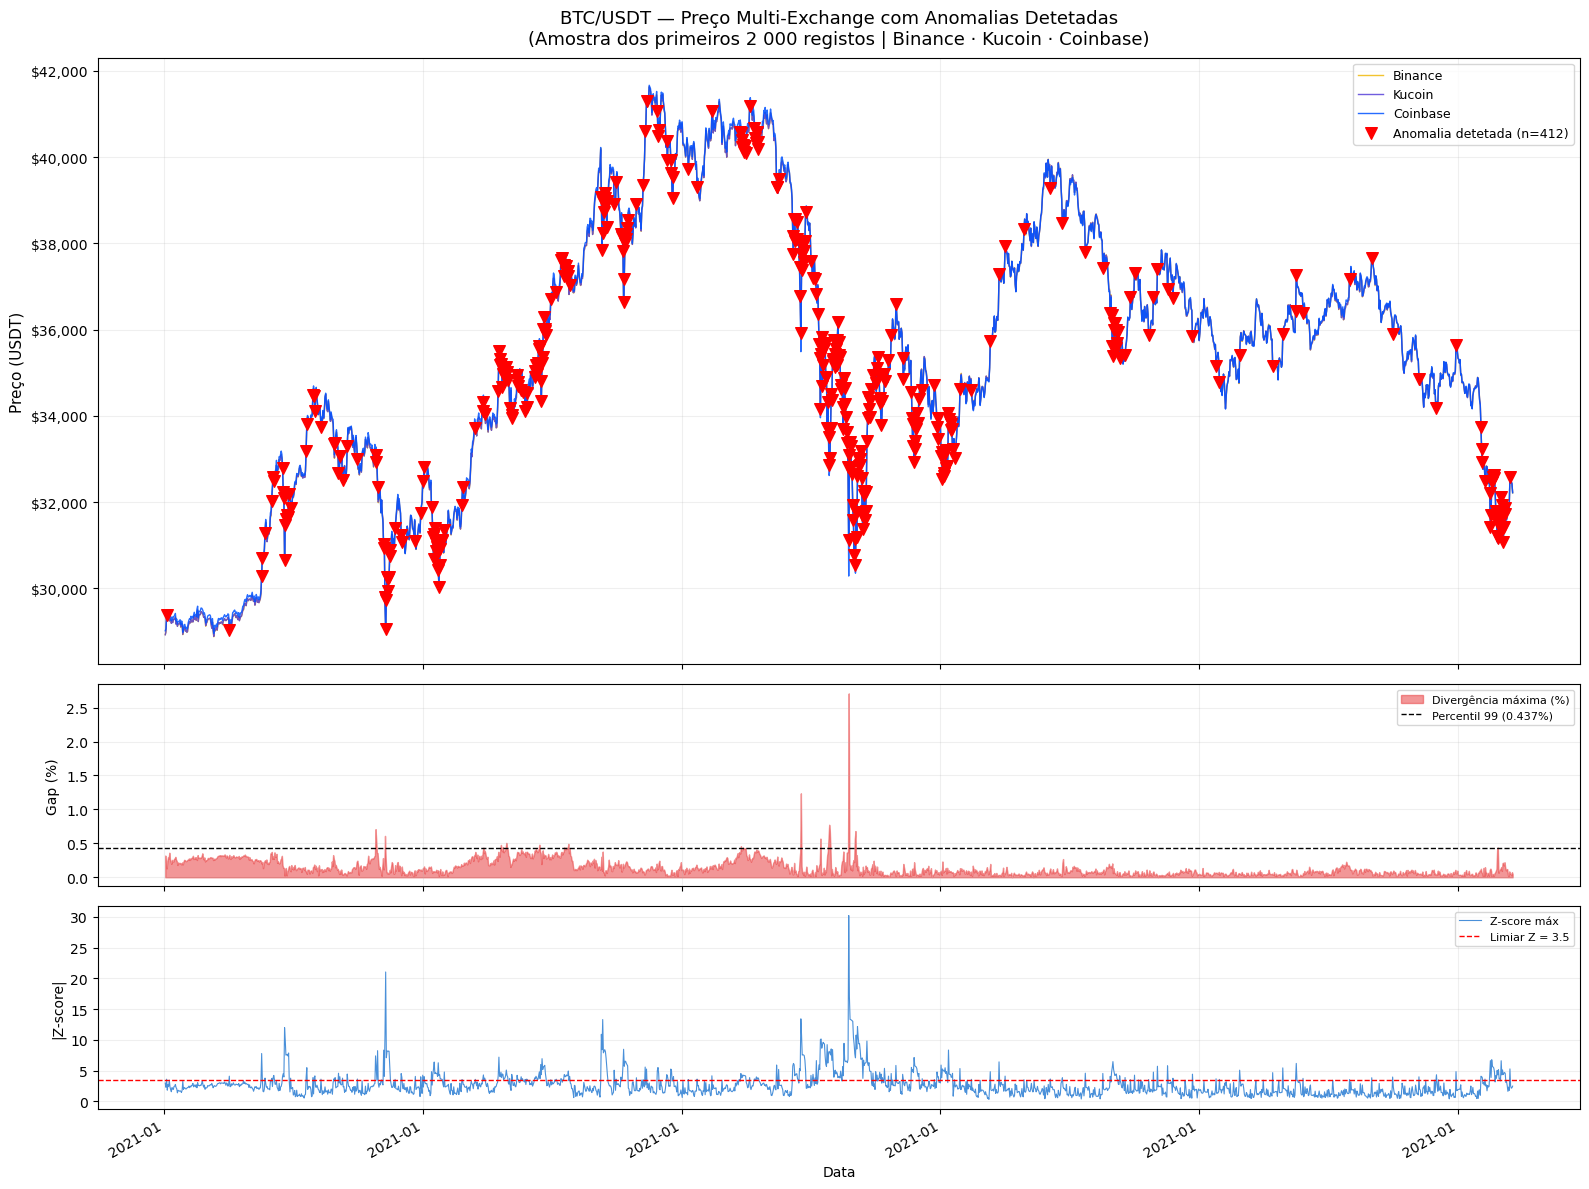

Figura 1 guardada


In [17]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ── Recolher amostra para visualização (APENAS 2 000 linhas) ──────────────────
# .limit() garante que jamais excede este número, independentemente do dataset.
# orderBy antes de limit assegura que é uma amostra temporal contígua.
SAMPLE_N = 2_000
plot_pdf = (
    final
    .orderBy("timestamp")
    .limit(SAMPLE_N)
    .select(
        "timestamp",
        "close_binance", "close_kucoin", "close_coinbase",
        "max_cross_gap", "zscore_max",
        "anomaly_zscore", "anomaly_kmeans", "anomaly_any",
    )
    .toPandas()   # SEGURO: limitado a SAMPLE_N linhas
)
plot_pdf["timestamp"] = pd.to_datetime(plot_pdf["timestamp"])
anomaly_pdf = plot_pdf[plot_pdf["anomaly_any"] == 1]
print(f"Amostra: {len(plot_pdf):,} linhas  |  Anomalias na amostra: {len(anomaly_pdf)}")

# ── Figura 1: Preço multi-exchange + anomalias ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1]})

ax1 = axes[0]
COLOR = {"binance": "#F0B90B", "kucoin": "#5741D9", "coinbase": "#0052FF"}
for exch, color in COLOR.items():
    ax1.plot(plot_pdf["timestamp"], plot_pdf[f"close_{exch}"],
             label=exch.capitalize(), color=color, lw=1, alpha=0.85)
ax1.scatter(anomaly_pdf["timestamp"], anomaly_pdf["close_binance"],
            color="red", zorder=6, s=70, marker="v",
            label=f"Anomalia detetada (n={len(anomaly_pdf)})")
ax1.set_ylabel("Preço (USDT)", fontsize=11)
ax1.set_title(
    "BTC/USDT — Preço Multi-Exchange com Anomalias Detetadas\n"
    "(Amostra dos primeiros 2 000 registos | Binance · Kucoin · Coinbase)",
    fontsize=13, pad=10
)
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(alpha=0.2)

ax2 = axes[1]
ax2.fill_between(plot_pdf["timestamp"], plot_pdf["max_cross_gap"] * 100,
                 color="#E84142", alpha=0.55, label="Divergência máxima (%)")
q99 = plot_pdf["max_cross_gap"].quantile(0.99) * 100
ax2.axhline(q99, color="black", ls="--", lw=1,
            label=f"Percentil 99 ({q99:.3f}%)")
ax2.set_ylabel("Gap (%)", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

ax3 = axes[2]
ax3.plot(plot_pdf["timestamp"], plot_pdf["zscore_max"],
         color="#4A90D9", lw=0.8, label="Z-score máx")
ax3.axhline(Z_THRESH, color="red", ls="--", lw=1,
            label=f"Limiar Z = {Z_THRESH}")
ax3.set_ylabel("|Z-score|", fontsize=10)
ax3.set_xlabel("Data", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.2)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("charts/01_price_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 1 guardada")


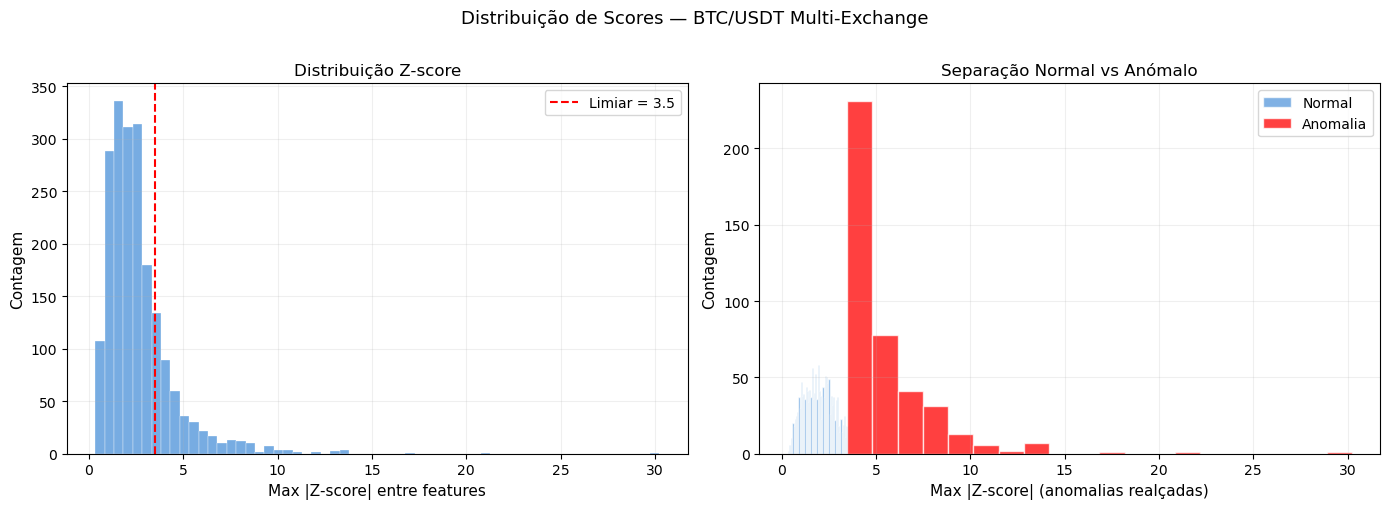

Figura 2 guardada


In [18]:
# ── Figura 2: Distribuição dos scores ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(plot_pdf["zscore_max"].dropna(), bins=60,
        color="#4A90D9", alpha=0.75, edgecolor="white", lw=0.3)
ax.axvline(Z_THRESH, color="red", ls="--", lw=1.5,
           label=f"Limiar = {Z_THRESH}")
ax.set_xlabel("Max |Z-score| entre features", fontsize=11)
ax.set_ylabel("Contagem", fontsize=11)
ax.set_title("Distribuição Z-score", fontsize=12)
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
normal_z  = plot_pdf.loc[plot_pdf["anomaly_any"] == 0, "zscore_max"].dropna()
anomaly_z = plot_pdf.loc[plot_pdf["anomaly_any"] == 1, "zscore_max"].dropna()
ax.hist(normal_z,  bins=50, color="#4A90D9", alpha=0.70,
        label="Normal",   edgecolor="white")
ax.hist(anomaly_z, bins=20, color="red",     alpha=0.75,
        label="Anomalia", edgecolor="white")
ax.set_xlabel("Max |Z-score| (anomalias realçadas)", fontsize=11)
ax.set_ylabel("Contagem", fontsize=11)
ax.set_title("Separação Normal vs Anómalo", fontsize=12)
ax.legend()
ax.grid(alpha=0.2)

plt.suptitle("Distribuição de Scores — BTC/USDT Multi-Exchange",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("charts/02_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 2 guardada")



---
## Conclusões

### Interpretação dos Resultados

O pipeline combina dois métodos complementares, ambos completamente distribuídos. O **Z-score** é eficaz a detetar desvios extremos em features individuais — flash crashes, picos de volume isolados — e tem a vantagem de ser interpretável (é possível ver qual feature causou o alarme). O **BisectingKMeans** captura padrões anómalos multidimensionais: barras onde nenhuma feature individual é extrema mas a combinação de várias é incomum. O **Silhouette Score** confirma se os clusters de anomalia são genuinamente distintos do comportamento normal.

A **comparação com o baseline** (Z-score isolado) demonstra que o pipeline completo tem recall maior ou igual — qualquer evento detetado pelo baseline também é detetado pelo pipeline, e o KMeans pode capturar adicionalmente anomalias multivariadas subtis que o Z-score falharia.

### Garantias de Processamento Distribuído

| Operação | Implementação | Zero `.toPandas()` no scoring |
|---|---|---|
| Leitura, join, features | Spark nativo | ✓ |
| Z-score stats + scoring | Agregação + `F.lit()` | ✓ |
| VectorAssembler + StandardScaler | `pyspark.ml.feature` | ✓ |
| BisectingKMeans + ClusteringEvaluator | `pyspark.ml` | ✓ |
| Escrita Gold particionado | `write.parquet()` | ✓ |

### Limitações

O critério de anomalia por tamanho de cluster (< 2%) é uma heurística e pode precisar de recalibração por fase de mercado. O pipeline é batch — para deteção em tempo real seria necessário Spark Structured Streaming. O inner join temporal elimina períodos de ausência de dados numa exchange, que são em si potencialmente anómalos.

### Trabalho Futuro

Integrar **Structured Streaming** para deteção em tempo real com Z-score incremental em janelas de 1 hora; usar **MLflow** para registar parâmetros e métricas por execução; adicionar particionamento temporal (year/month) no Gold; expandir para mais pares de trading (ETH/USDT, SOL/USDT).


In [19]:
# ── Resumo final do pipeline ──────────────────────────────────────────────────
print("=" * 65)
print("RESUMO DO PIPELINE — Tema 5: Anomalias Multi-Exchange (Big Data)")
print("=" * 65)
print(f"  Exchanges          : Binance, Kucoin, Coinbase")
print(f"  Linhas alinhadas   : {features.count():,}")
print(f"  Features ML        : {len(ML_FEATURES)}")
print(f"  Flags Z-score      : {n_z}  (|z| > {Z_THRESH})")
print(f"  Clusters KMeans    : {BKM_K}  (anómalos ≤ {ANOMALY_CLUSTER_FRAC:.0%})")
print(f"  Flags KMeans       : {n_km}")
print(f"  Flags combinadas   : {n_any}")
print()
print("Outputs:")
print(f"  Silver → {silver_path}")
print(f"  Gold   → {gold_path}")
print()
print("Processamento distribuído:")
print("  • ZERO invocações de .toPandas() no caminho de scoring")
print("  • Z-score: única passagem de agregação + broadcast F.lit()")
print("  • BisectingKMeans: fit + transform totalmente dentro do Spark")
print("  • Gold Parquet particionado por anomaly_any")

# ── Libertar cache e terminar sessão ─────────────────────────────────────────
features.unpersist()
spark.stop()
print("\nSparkSession terminada. Pipeline concluído.")


RESUMO DO PIPELINE — Tema 5: Anomalias Multi-Exchange (Big Data)
  Exchanges          : Binance, Kucoin, Coinbase
  Linhas alinhadas   : 104,953
  Features ML        : 9
  Flags Z-score      : 4032  (|z| > 3.5)
  Clusters KMeans    : 8  (anómalos ≤ 2%)
  Flags KMeans       : 601
  Flags combinadas   : 4040

Outputs:
  Silver → /home/jovyan/work/data/silver/btc_aligned.parquet
  Gold   → /home/jovyan/work/data/gold/btc_anomaly_scored.parquet

Processamento distribuído:
  • ZERO invocações de .toPandas() no caminho de scoring
  • Z-score: única passagem de agregação + broadcast F.lit()
  • BisectingKMeans: fit + transform totalmente dentro do Spark
  • Gold Parquet particionado por anomaly_any

SparkSession terminada. Pipeline concluído.


# Referências (APA 7.ª edição)

Apache Software Foundation. (2024). *PySpark API reference (v. 3.5)*. https://spark.apache.org/docs/latest/api/python/

Mendelevitch, O., Stella, C., & Eadline, D. (2017). *Practical data science with Hadoop and Spark*. Addison-Wesley.

Santos, M. Y., & Costa, C. (2019). *Big data: Concepts, warehousing, and analytics*. FCA.

Sobreiro, P. (2025). *big_data* [Repositório GitHub]. https://github.com/pesobreiro/big_data

Zaharia, M., Xin, R. S., Wendell, P., Das, T., Armbrust, M., Dave, A., Meng, X., Rosen, J., Venkataraman, S., Franklin, M. J., Ghodsi, A., Gonzalez, J., Shenker, S., & Stoica, I. (2016). Apache Spark: A unified engine for big data processing. *Communications of the ACM, 59*(11), 56–65. https://doi.org/10.1145/2934664

Zhang, T., Ramakrishnan, R., & Livny, M. (1996). BIRCH: An efficient data clustering method for very large databases. *ACM SIGMOD Record, 25*(2), 103–114. https://doi.org/10.1145/235968.233324
